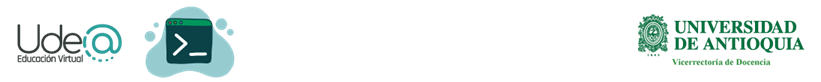

# <h1><center>Tutorial Isolation Forest</center></h1>

**Especialización en Analítica de Datos**

*Prof. Hernán Felipe García Arias*

*Facultad de Ingeniería*

*Universidad de Antioquia*


**2025-1**


<h2>📌 Isolation Forest: Anomaly Detection Technique</h2>

<h3>🔹 Introduction</h3>
<p>Isolation Forest is a powerful unsupervised anomaly detection method based on decision trees. Unlike traditional density-based anomaly detection techniques, it explicitly isolates anomalies instead of profiling normal data points.</p>

<hr>

<h3>🔹 Mathematical Foundations</h3>

<p>The Isolation Forest algorithm is based on random partitioning of data. It constructs multiple binary trees (Isolation Trees or iTrees), recursively selecting random split points along feature dimensions. Anomalies are expected to be isolated in fewer splits compared to normal points.</p>

<h4>📌 Anomaly Score Computation</h4>
<p>For a dataset \( X \) with \( n \) samples, the Isolation Forest algorithm works as follows:</p>

<ul>
  <li>Randomly selects a feature \( f_i \) and splits the data at a random threshold.</li>
  <li>Constructs an isolation tree until each instance is isolated or reaches a predefined depth.</li>
  <li>Repeats the process for multiple trees to form a forest.</li>
  <li>Computes the anomaly score based on the average path length of a sample across all trees.</li>
</ul>

<p>The anomaly score for a given sample \( x \) is computed as:</p>

$$
s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}
$$

<p>where:</p>
<ul>
  <li>\( E(h(x)) \) is the average path length for \( x \).</li>
  <li>\( c(n) \) is the average path length for a normal point in a dataset of size \( n \):</li>
</ul>

$$
c(n) = 2 H(n-1) - \frac{2(n-1)}{n}
$$

<p>where \( H(n) \) is the harmonic number:</p>

$$
H(n) = \sum_{i=1}^{n} \frac{1}{i}
$$

<p>Anomalies have shorter path lengths, leading to higher anomaly scores.</p>

<hr>

<h3>🔹 Implementation Steps in Google Colab</h3>

<h4>📌 Step 1: Import Required Libraries</h4>

<p>The first step in the notebook is to import the necessary libraries:</p>

In [1]:
## Isolation Forest Tutorial - Google Colab Notebook

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs, load_digits
from sklearn.preprocessing import StandardScaler

<h4>📌 Step 2: Generate Synthetic Data</h4> <p>We generate a dataset containing both normal and anomalous samples:</p>

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Function to plot decision boundaries for Isolation Forest
def plot_isolation_forest(X, clf, title):
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min(), X[:, 0].max(), 100),
                         np.linspace(X[:, 1].min(), X[:, 1].max(), 100))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 10), cmap=plt.cm.Blues_r)
    plt.colorbar()
    plt.scatter(X[:, 0], X[:, 1], c='red', edgecolor='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Generate synthetic dataset with outliers
X_inliers, _ = make_blobs(n_samples=200, centers=[[0, 0], [5, 5]], cluster_std=0.8, random_state=42)
X_outliers = np.random.uniform(low=-6, high=10, size=(20, 2))
X = np.vstack((X_inliers, X_outliers))

<p>This dataset contains two clusters with some randomly distributed outliers.</p> <h4>📌 Step 3: Train the Isolation Forest Model</h4> <p>We train an Isolation Forest model with 100 estimators and a contamination rate of 10%:</p>

In [3]:
# Train Isolation Forest
clf = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
clf.fit(X)

# Predict anomaly scores
preds = clf.predict(X)

<p>The <code>contamination</code> parameter represents the proportion of anomalies expected in the dataset.</p> <h4>📌 Step 4: Visualizing Decision Boundaries</h4> <p>We visualize how the Isolation Forest partitions the data:</p>

In [4]:
preds

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1, -1,
        1, -1, -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1])

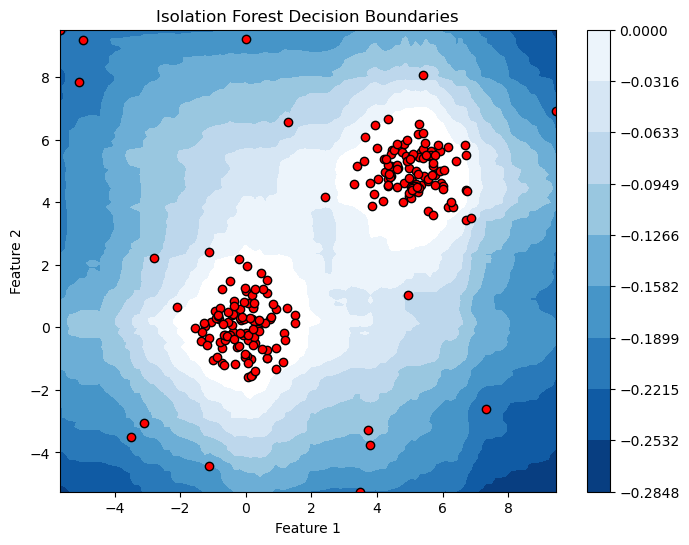

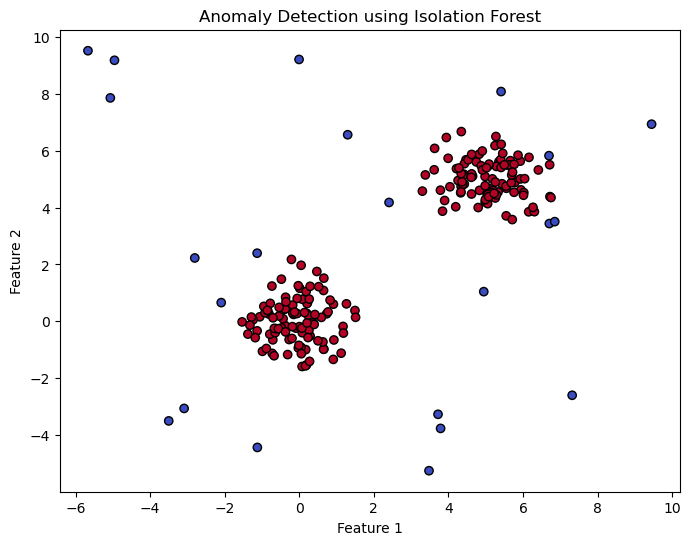

In [5]:
# Plot decision boundaries
plot_isolation_forest(X, clf, "Isolation Forest Decision Boundaries")

# Display outlier predictions
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=preds, cmap='coolwarm', edgecolor='k')
plt.title("Anomaly Detection using Isolation Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

<p>Calling this function gives an intuitive visualization of how the model detects anomalies.</p> <h4>📌 Step 5: Apply Isolation Forest on a Real-World Dataset</h4> <p>We apply the model to the **Digits Dataset** from Scikit-learn:</p>

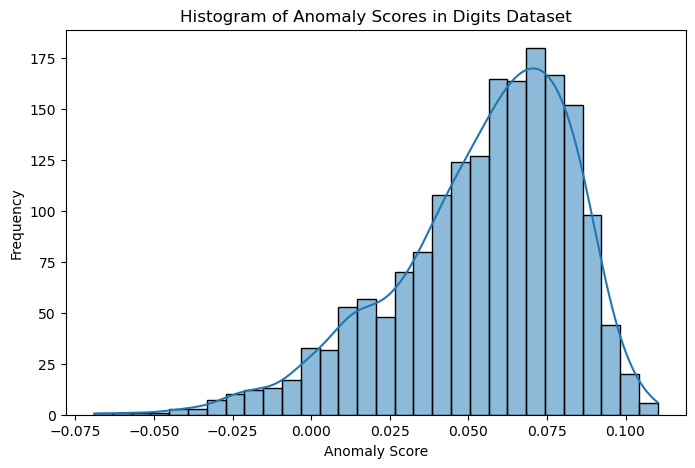

Number of detected anomalies in Digits dataset: 90


In [6]:
# Load real-world dataset (Digits dataset)
digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)

# Apply Isolation Forest
clf_digits = IsolationForest(contamination=0.05, random_state=42)
clf_digits.fit(X_digits)
anomaly_scores = clf_digits.decision_function(X_digits)
preds_digits = clf_digits.predict(X_digits)

# Histogram of anomaly scores
plt.figure(figsize=(8, 5))
sns.histplot(anomaly_scores, bins=30, kde=True)
plt.title("Histogram of Anomaly Scores in Digits Dataset")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

# Count anomalies
num_anomalies = np.sum(preds_digits == -1)
print(f"Number of detected anomalies in Digits dataset: {num_anomalies}")


In [7]:
aux = X_digits[preds_digits == -1]

<p>This helps us understand how well the model distinguishes normal from anomalous digits.</p> <hr> <h3>🔹 Discussion and Key Insights</h3> <ul> <li><b>Random Partitioning:</b> Unlike clustering-based methods, Isolation Forest does not assume a specific data distribution.</li> <li><b>Linear Time Complexity:</b> The algorithm scales efficiently for large datasets.</li> <li><b>Interpretability:</b> Shorter path lengths indicate anomalies, making it intuitive to interpret.</li> <li><b>Robustness:</b> Works well on both structured and unstructured datasets.</li> </ul> <hr> <h3>🔹 Questions for Discussion</h3> <p>To deepen understanding, consider the following questions:</p> <ol> <li>How does the **contamination** parameter affect the anomaly detection results?</li> <li>What would happen if we **increase** the number of estimators in the Isolation Forest?</li> <li>Compare Isolation Forest with other anomaly detection techniques such as **DBSCAN** or **One-Class SVM**. When would you prefer one over the other?</li> </ol> <hr> <h3>📌 Hint</h3> <p>Isolation Forest is a highly efficient and effective technique for anomaly detection. It relies on recursive partitioning, where anomalies are expected to be isolated in fewer splits than normal points. This method is computationally efficient and works well across various datasets, making it a popular choice for detecting rare events, fraudulent activities, and system faults.</p>

### Cambio del parametro contaminacion

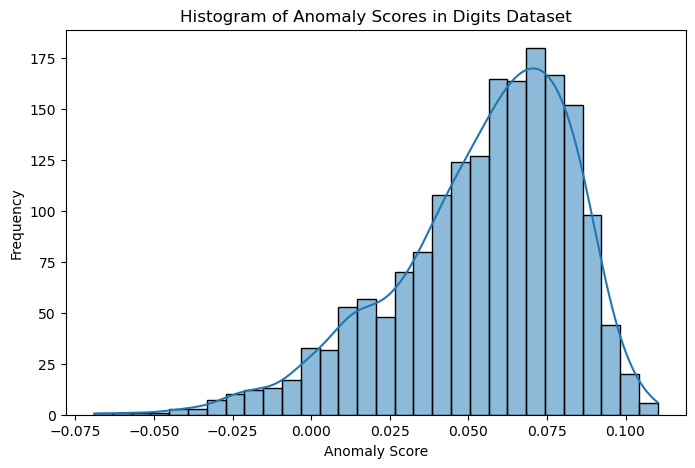

Number of detected anomalies in Digits dataset: 90


In [8]:
# Apply Isolation Forest
clf_digits = IsolationForest(contamination=0.05, random_state=42)
clf_digits.fit(X_digits)
anomaly_scores = clf_digits.decision_function(X_digits)
preds_digits = clf_digits.predict(X_digits)

# Histogram of anomaly scores
plt.figure(figsize=(8, 5))
sns.histplot(anomaly_scores, bins=30, kde=True)
plt.title("Histogram of Anomaly Scores in Digits Dataset")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

# Count anomalies
num_anomalies = np.sum(preds_digits == -1)
print(f"Number of detected anomalies in Digits dataset: {num_anomalies}")

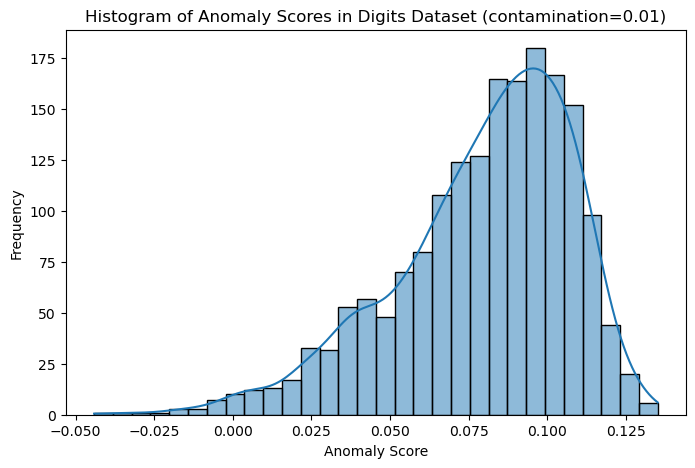

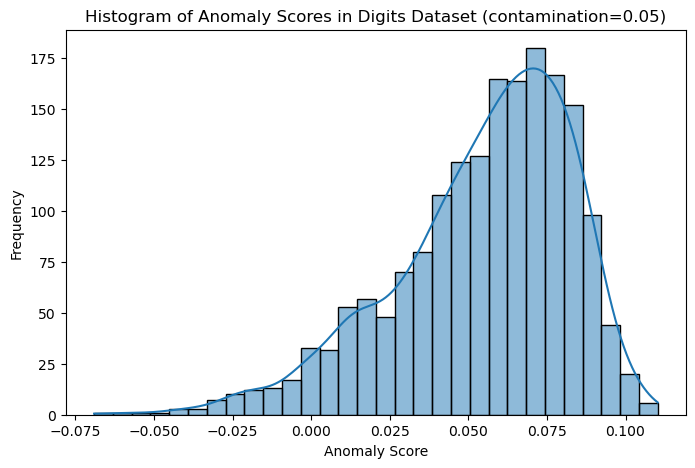

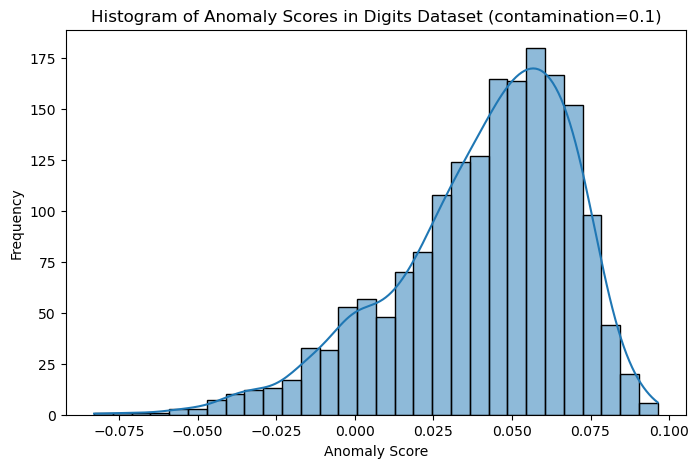

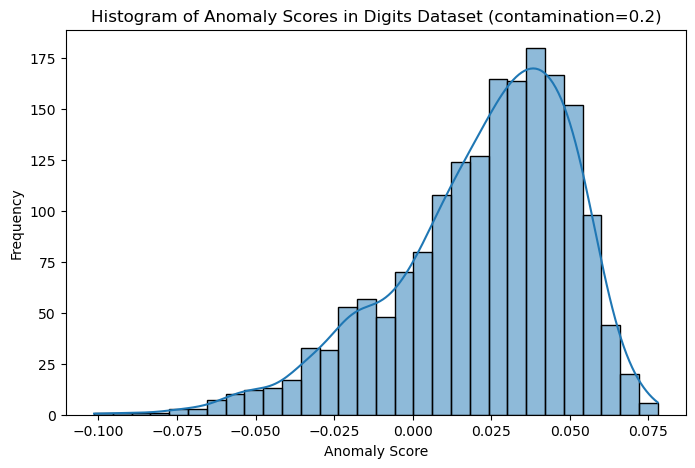

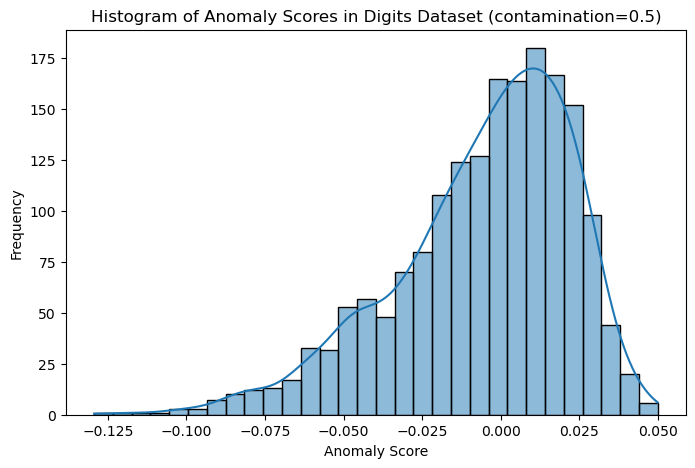

Text(0.5, 1.0, 'Number of Detected Anomalies vs. Contamination Parameter')

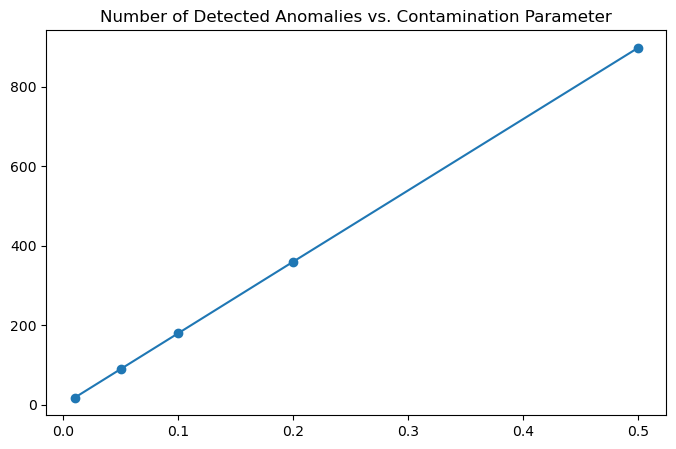

In [13]:
# Apply Isolation Forest with different contamination parameter
contaminations = [0.01, 0.05, 0.1, 0.2, 0.5]
num_anomalies = []
anomaly_scores = []
for contamination in contaminations:
    clf_digits = IsolationForest(contamination=contamination, random_state=42)
    clf_digits.fit(X_digits)
    anomaly_scores.append(clf_digits.decision_function(X_digits))
    preds_digits = clf_digits.predict(X_digits)
    num_anomalies.append(np.sum(preds_digits == -1))
    # Histogram of anomaly scores
    plt.figure(figsize=(8, 5))
    sns.histplot(anomaly_scores[-1], bins=30, kde=True)
    plt.title(f"Histogram of Anomaly Scores in Digits Dataset (contamination={contamination})")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.show()
    # print(f"Number of detected anomalies in Digits dataset with contamination={contamination}: {anomaly_scores[-1]}")

# Plot number of anomalies vs. contamination
plt.figure(figsize=(8, 5))
plt.plot(contaminations, num_anomalies, marker='o')
plt.title("Number of Detected Anomalies vs. Contamination Parameter")   

Lo anterior por promt

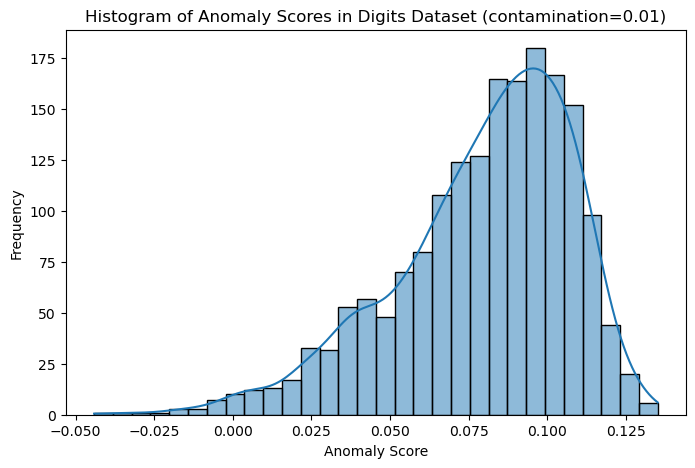

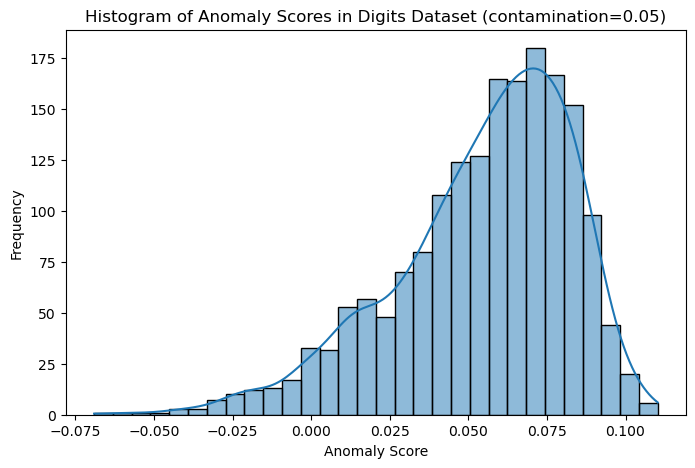

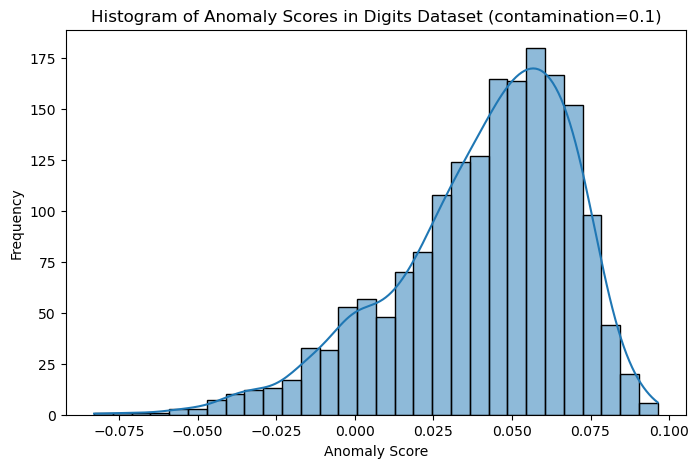

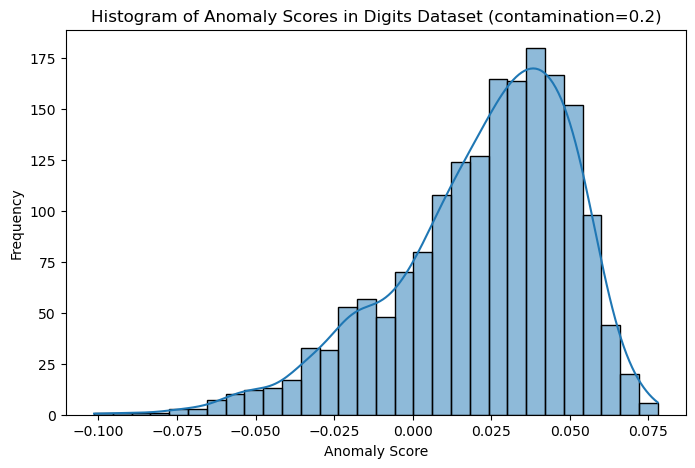

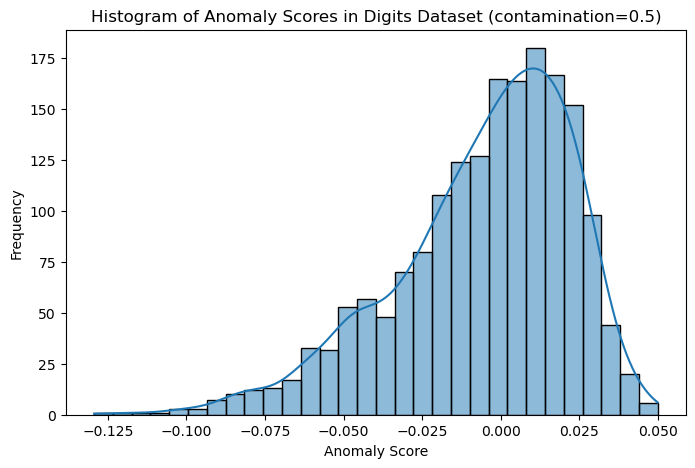

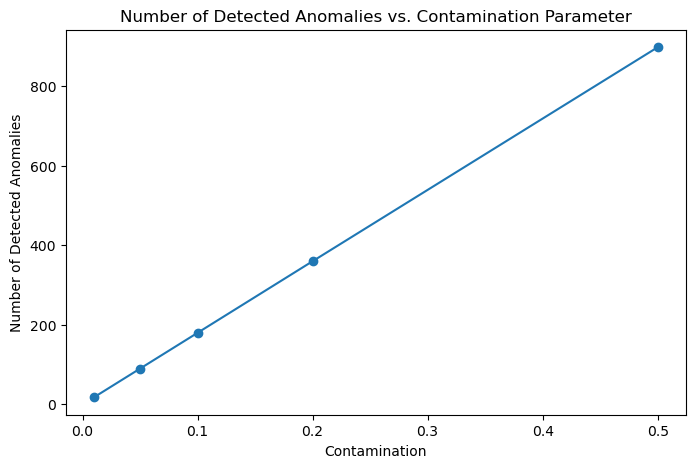

In [15]:
# Apply Isolation Forest with different contamination parameter
contaminations = [0.01, 0.05, 0.1, 0.2, 0.5]
num_anomalies = []
anomaly_scores = []
for contamination in contaminations:
    clf_digits = IsolationForest(contamination=contamination, random_state=42)
    clf_digits.fit(X_digits)
    anomaly_scores.append(clf_digits.decision_function(X_digits))
    preds_digits = clf_digits.predict(X_digits)
    num_anomalies.append(np.sum(preds_digits == -1))
    # Histogram of anomaly scores
    plt.figure(figsize=(8, 5))
    sns.histplot(anomaly_scores[-1], bins=30, kde=True)
    plt.title(f"Histogram of Anomaly Scores in Digits Dataset (contamination={contamination})")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.show()

# Plot number of anomalies vs. contamination
plt.figure(figsize=(8, 5))
plt.plot(contaminations, num_anomalies, marker='o')
plt.title("Number of Detected Anomalies vs. Contamination Parameter")
plt.xlabel("Contamination")
plt.ylabel("Number of Detected Anomalies")
plt.show()

A mas contaminacion mas información que no se toma, recordemos la colita de la izquierda que es la que esta sacando lo anomalo. A menor contaminación menos outlier-

La segunda pregunta por promt

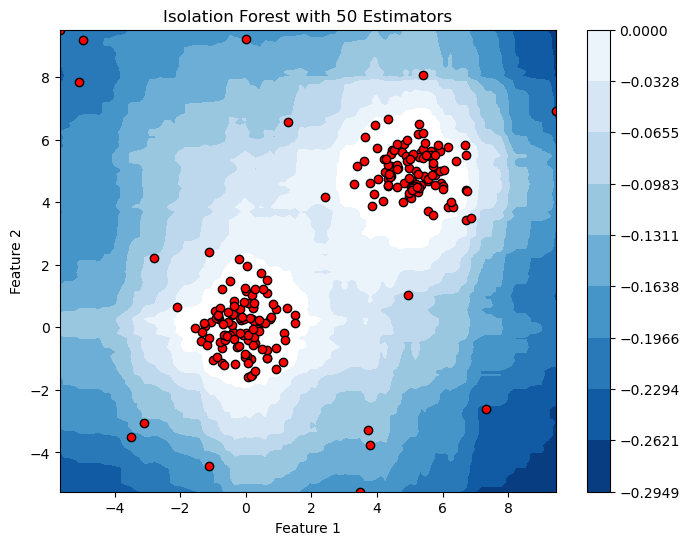

Number of estimators: 50
Number of detected anomalies: 22



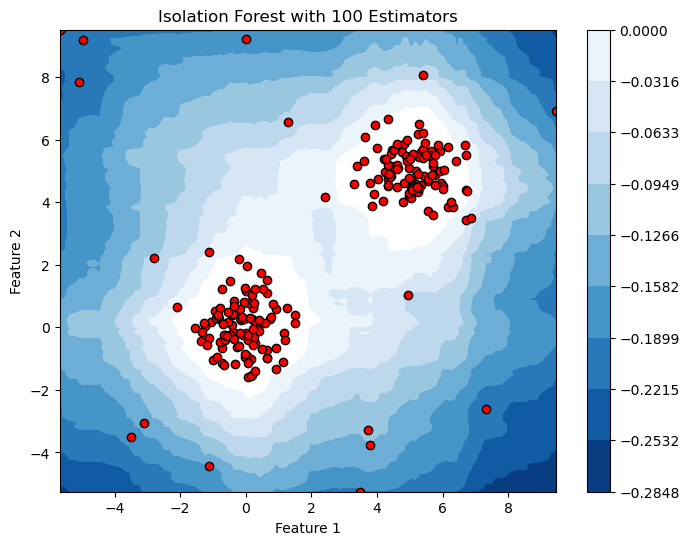

Number of estimators: 100
Number of detected anomalies: 22



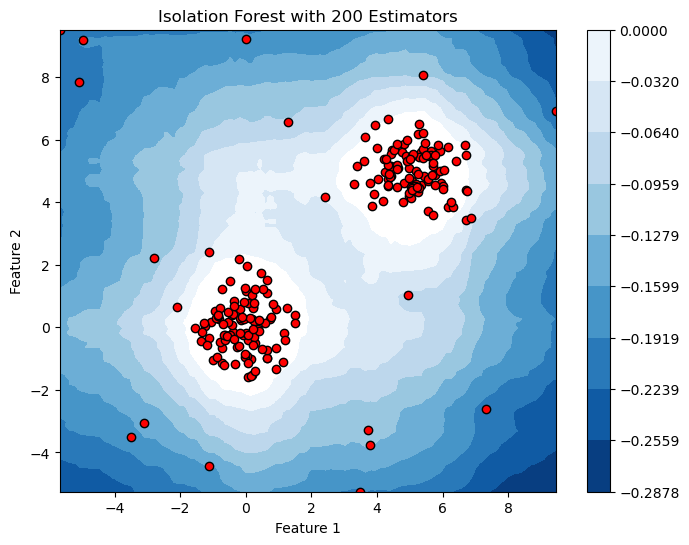

Number of estimators: 200
Number of detected anomalies: 22



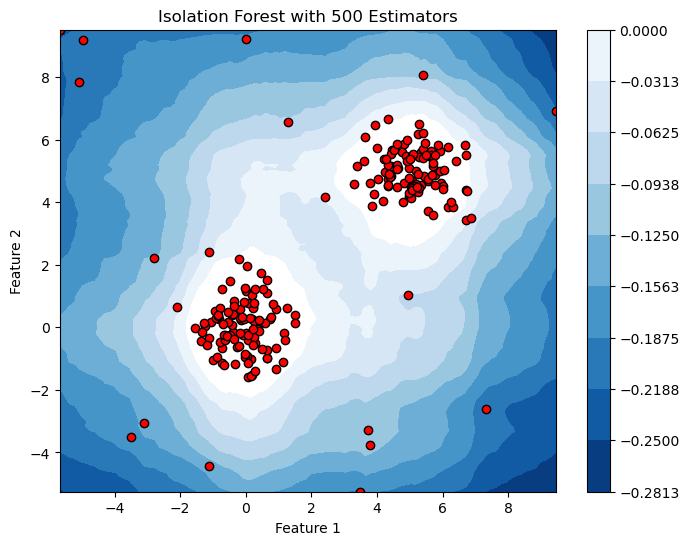

Number of estimators: 500
Number of detected anomalies: 22



In [14]:
# Define a function to train Isolation Forest with different number of estimators
def train_isolation_forest_with_estimators(X, n_estimators_list):
    for n_estimators in n_estimators_list:
        clf = IsolationForest(n_estimators=n_estimators, contamination=0.1, random_state=42)
        clf.fit(X)
        preds = clf.predict(X)
        plot_isolation_forest(X, clf, f"Isolation Forest with {n_estimators} Estimators")
        print(f"Number of estimators: {n_estimators}")
        print(f"Number of detected anomalies: {np.sum(preds == -1)}\n")

# List of different number of estimators to try
n_estimators_list = [50, 100, 200, 500]

# Train and plot results
train_isolation_forest_with_estimators(X, n_estimators_list)

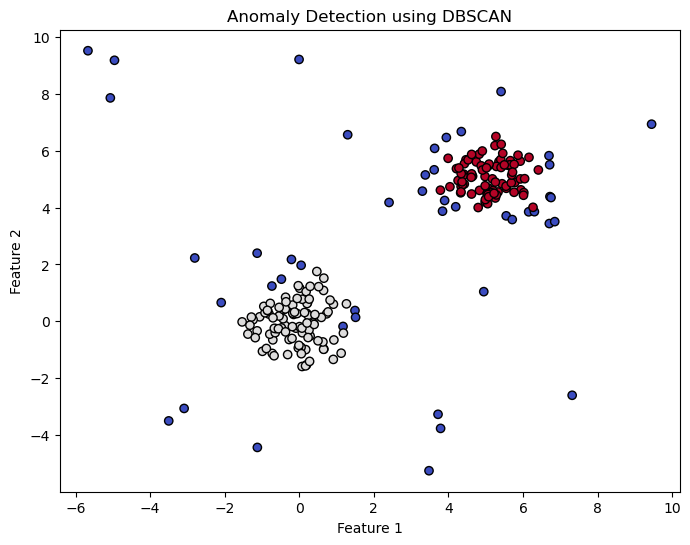

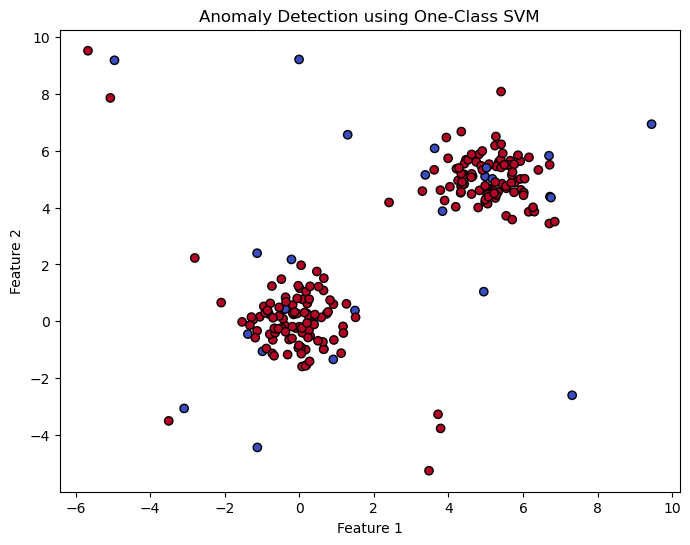

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.svm import OneClassSVM

# DBSCAN for anomaly detection
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Plot DBSCAN results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='coolwarm', edgecolor='k')
plt.title("Anomaly Detection using DBSCAN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# One-Class SVM for anomaly detection
ocsvm = OneClassSVM(kernel='rbf', gamma='auto', nu=0.1)
ocsvm.fit(X)
ocsvm_labels = ocsvm.predict(X)

# Plot One-Class SVM results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=ocsvm_labels, cmap='coolwarm', edgecolor='k')
plt.title("Anomaly Detection using One-Class SVM")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

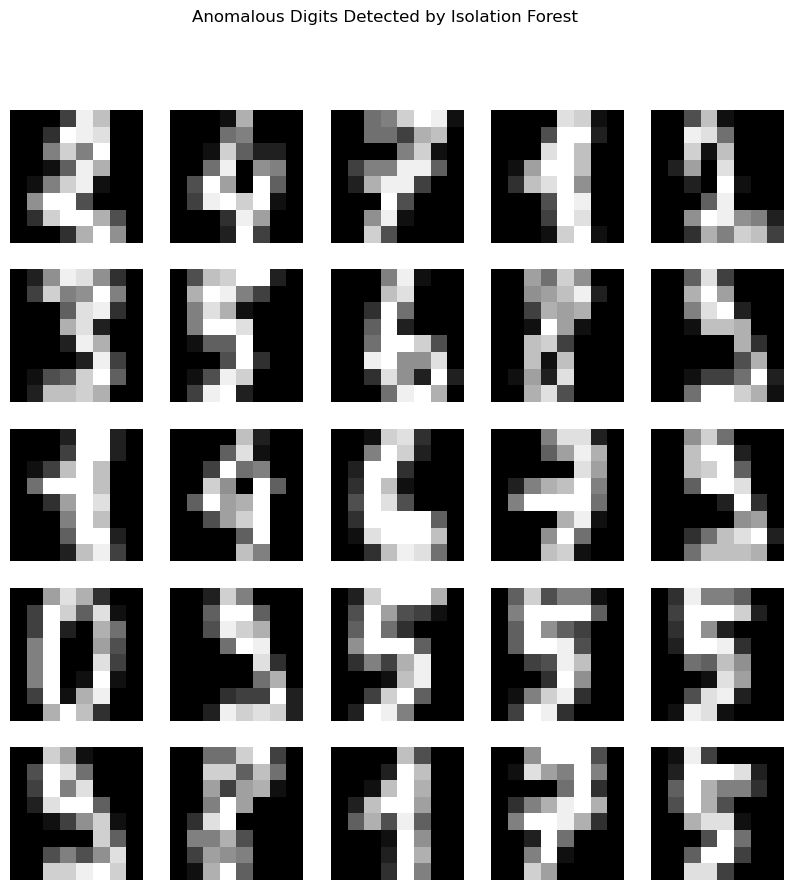

In [17]:
# Graficar los dígitos anómalos detectados
anomalous_digits = digits.images[preds_digits == -1]

plt.figure(figsize=(10, 10))
for i in range(min(len(anomalous_digits), 25)):
    plt.subplot(5, 5, i + 1)
    plt.imshow(anomalous_digits[i], cmap='gray')
    plt.axis('off')
plt.suptitle("Anomalous Digits Detected by Isolation Forest")
plt.show()